Q1: To what extent does the daily average news Tone for an organization influence its next-day stock price movement?

In [2]:
THEME_DATA_PATH="./files/cleaned_data-themes_with_prices_clean_000000000000.csv" # This is the path to the themes data file
SENTIMENT_DATA_PATH="./files/cleaned_data-combined_data_clean_000000000000-2.csv" # This is the path to the sentiment data file
OUTPUT_PATH="./results" # This is where the theme importance results will be saved

In [ ]:

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
 
 
def load_data(data_path):
    """Load the cleaned combined dataset."""
    df = pd.read_csv(data_path, parse_dates=["event_date"])
    df = df.dropna(subset=["daily_avg_tone", "next_day_close", "daily_return_pct"])
    print(f"Loaded {len(df)} rows from {data_path}")
    print(f"Companies: {df['company'].unique()}")
    print(f"Date range: {df['event_date'].min()} to {df['event_date'].max()}")
    return df
 
def run_tone_correlations(df):
    """
    Run Pearson correlation for each company:
      - daily_avg_tone vs next_day_close  (tone vs price level)
      - daily_avg_tone vs daily_return_pct (tone vs daily movement)
    
    pearsonr() returns (r_value, p_value) in one call.
    p < 0.05 = statistically significant = reject the null hypothesis.
    """
    results = []
 
    for company in sorted(df["company"].unique()):
        company_df = df[df["company"] == company]
        n = len(company_df)
 
        r_close, p_close = pearsonr(
            company_df["daily_avg_tone"], company_df["next_day_close"]
        )
 
        r_return, p_return = pearsonr(
            company_df["daily_avg_tone"], company_df["daily_return_pct"]
        )
 
        results.append({
            "company": company,
            "n_observations": n,
            "tone_vs_close_r": round(r_close, 4),
            "tone_vs_close_p": round(p_close, 6),
            "tone_vs_close_significant": "Yes" if p_close < 0.05 else "No",
            "tone_vs_return_r": round(r_return, 4),
            "tone_vs_return_p": round(p_return, 6),
            "tone_vs_return_significant": "Yes" if p_return < 0.05 else "No",
        })
 
    results_df = pd.DataFrame(results)
    return results_df
 
 
def print_results(results_df):
    """Print results in a clear format with hypothesis test interpretation."""
    print("\n" + "=" * 70)
    print("Q1 RESULTS: To what extent does the daily average news Tone for an organization influence its next-day stock price movement?")
    print("=" * 70)
    print(f"Null hypothesis: No significant relationship between tone and price")
    print(f"Significance level: alpha = 0.05")
    print("-" * 70)
 
    for _, row in results_df.iterrows():
        print(f"\n{row['company']} (n={row['n_observations']}):")
        print(f"  Tone vs Next-Day Close:  r={row['tone_vs_close_r']:.4f}, "
              f"p={row['tone_vs_close_p']:.6f}  --> "
              f"{'REJECT null (significant)' if row['tone_vs_close_significant'] == 'Yes' else 'FAIL TO REJECT null (not significant)'}")
        print(f"  Tone vs Daily Return %:  r={row['tone_vs_return_r']:.4f}, "
              f"p={row['tone_vs_return_p']:.6f}  --> "
              f"{'REJECT null (significant)' if row['tone_vs_return_significant'] == 'Yes' else 'FAIL TO REJECT null (not significant)'}")
 
    print("\n" + "-" * 70)
    print("INTERPRETATION:")
    print("  Weak r with significant p for price levels = likely spurious")
    print("  (shared long-term trends, not tone predicting price)")
    print("  No significance for daily returns = tone does NOT predict movement")
    print("=" * 70)
 
 
df = load_data(SENTIMENT_DATA_PATH)
results_df = run_tone_correlations(df)
print_results(results_df)
results_path = os.path.join(OUTPUT_PATH, "q1_tone_correlation_results.csv")
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")


Loaded 6518 rows from ./files/cleaned_data-combined_data_clean_000000000000-2.csv
Companies: ['Aramco' 'Amazon' 'Pfizer']
Date range: 2020-01-02 00:00:00 to 2025-12-30 00:00:00

Q1 RESULTS: Does daily news tone influence stock price movement?
Null hypothesis: No significant relationship between tone and price
Significance level: alpha = 0.05
----------------------------------------------------------------------

Amazon (n=2173):
  Tone vs Next-Day Close:  r=0.1936, p=0.000000  --> REJECT null (significant)
  Tone vs Daily Return %:  r=-0.0223, p=0.298705  --> FAIL TO REJECT null (not significant)

Aramco (n=2172):
  Tone vs Next-Day Close:  r=0.2591, p=0.000000  --> REJECT null (significant)
  Tone vs Daily Return %:  r=0.0339, p=0.114418  --> FAIL TO REJECT null (not significant)

Pfizer (n=2173):
  Tone vs Next-Day Close:  r=0.0778, p=0.000284  --> REJECT null (significant)
  Tone vs Daily Return %:  r=0.0126, p=0.556177  --> FAIL TO REJECT null (not significant)

-------------------

Fig 1.1: Plotting daily average tone score vs closing price for each company.

['Amazon', 'Aramco', 'Pfizer']


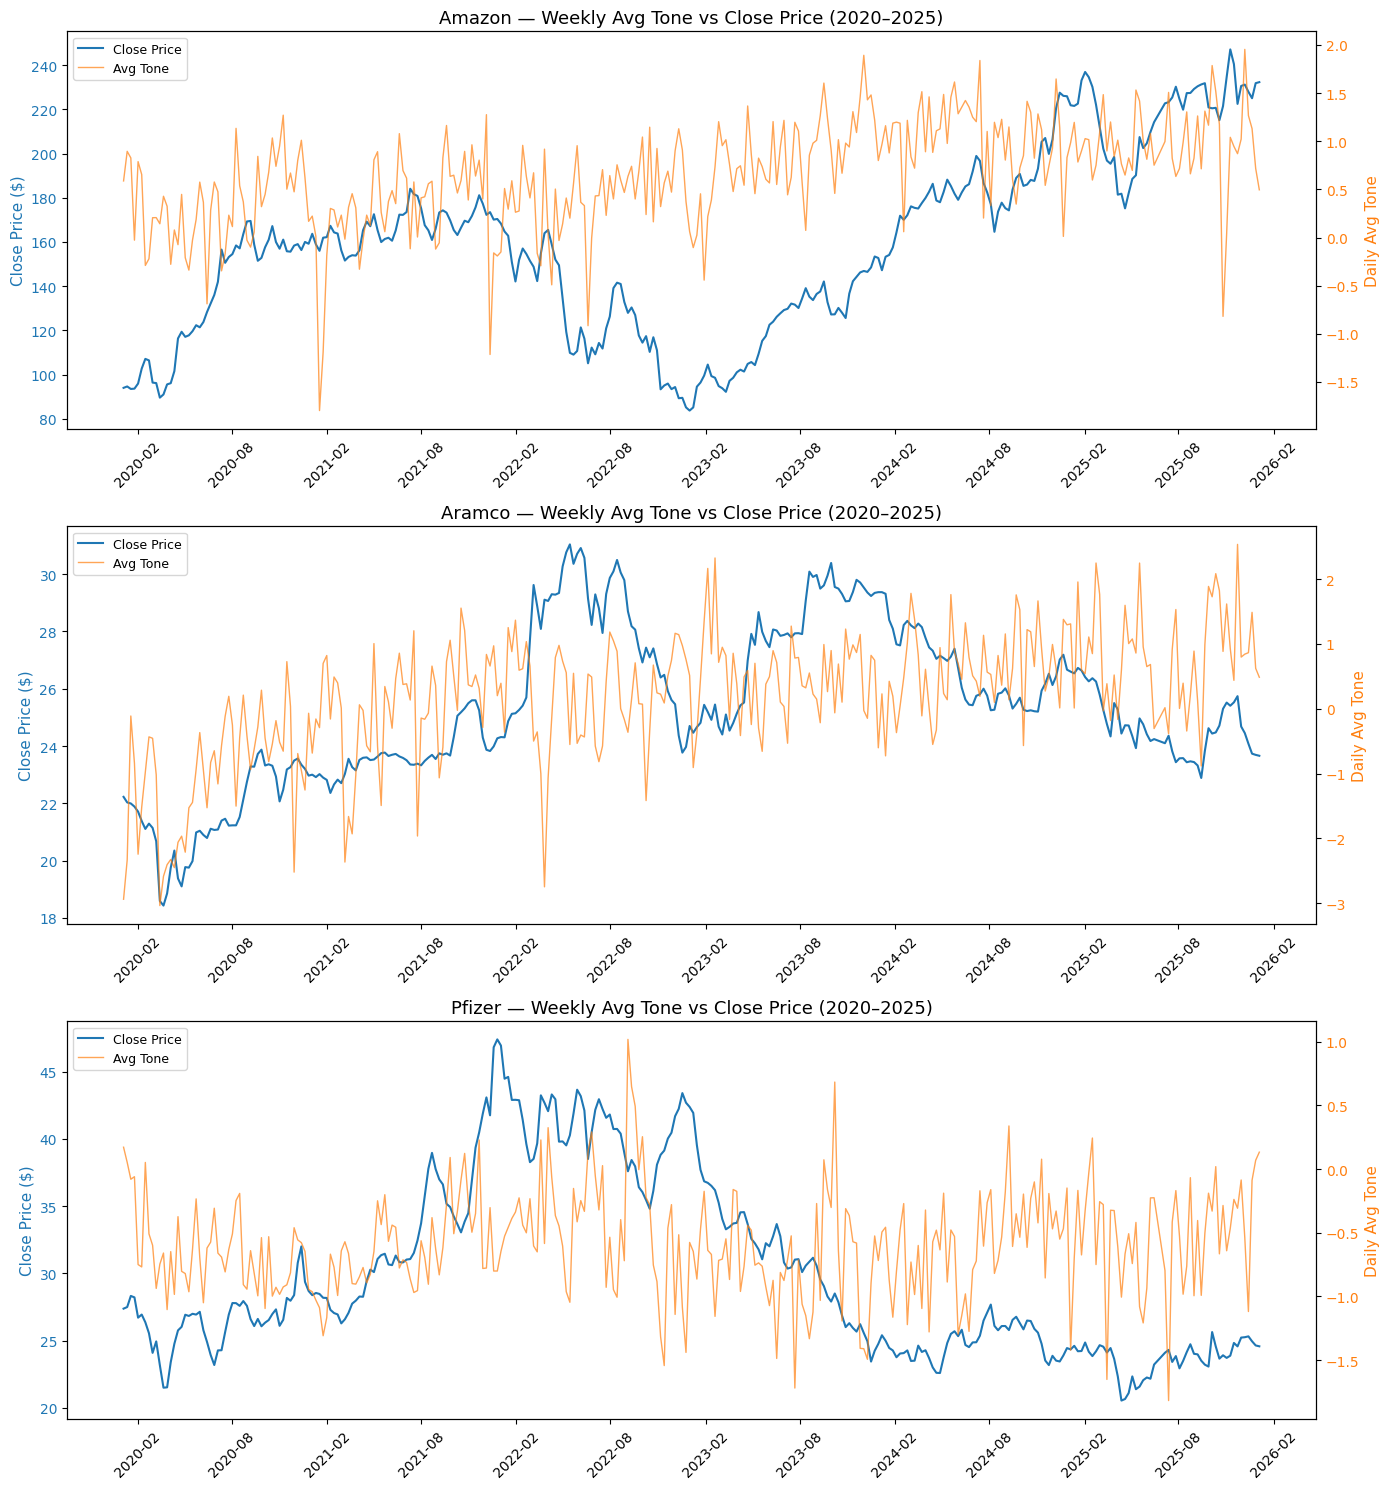

In [7]:

companies = sorted(df["company"].unique())
print(companies)
fig, axes = plt.subplots(len(companies), 1, figsize=(14, 5 * len(companies)))
 
if len(companies) == 1:
    axes = [axes]

for ax, company in zip(axes, companies):
    company_df = df[df["company"] == company].sort_values("event_date")

    # Resample to weekly averages so the chart isn't too noisy
    company_df = company_df.set_index("event_date")
    weekly = company_df.resample("W").agg({
        "daily_avg_tone": "mean",
        "Close": "mean"
    }).dropna()

    # Left y-axis: stock price
    color_price = "#1f77b4"
    ax.plot(weekly.index, weekly["Close"], color=color_price, linewidth=1.5, label="Close Price")
    ax.set_ylabel("Close Price ($)", color=color_price, fontsize=11)
    ax.tick_params(axis="y", labelcolor=color_price)

    # Right y-axis: tone
    ax2 = ax.twinx()
    color_tone = "#ff7f0e"
    ax2.plot(weekly.index, weekly["daily_avg_tone"], color=color_tone, linewidth=1, alpha=0.7, label="Avg Tone")
    ax2.set_ylabel("Daily Avg Tone", color=color_tone, fontsize=11)
    ax2.tick_params(axis="y", labelcolor=color_tone)

    ax.set_title(f"{company} — Weekly Avg Tone vs Close Price (2020–2025)", fontsize=13)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Fig 1.2: Bar chart comparing r-values across companies for both metrics.

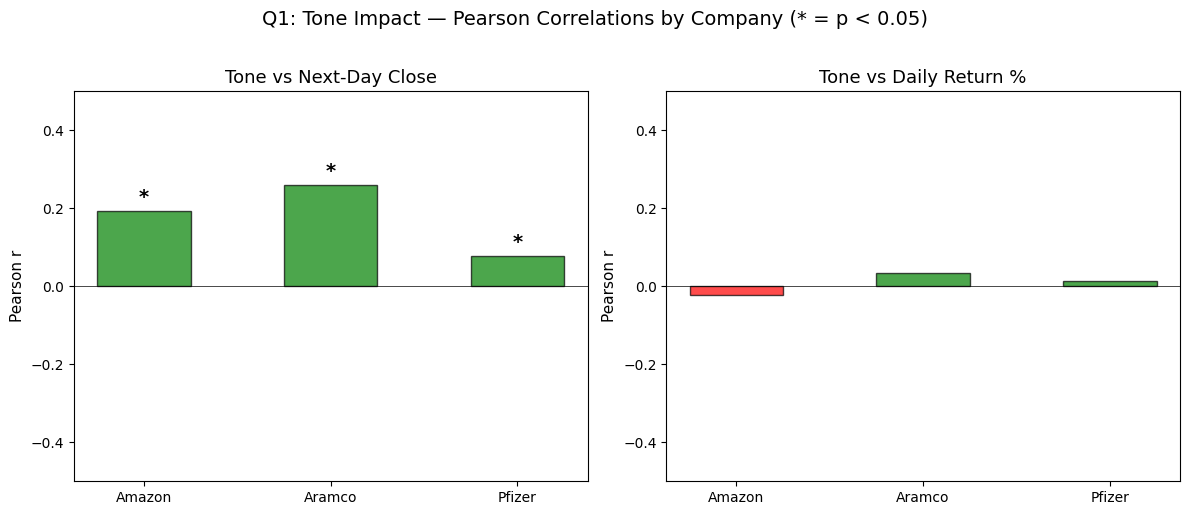

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

companies = results_df["company"]
x = np.arange(len(companies))
width = 0.5

# Tone vs Close
colors_close = ["green" if r > 0 else "red" for r in results_df["tone_vs_close_r"]]
bars1 = axes[0].bar(x, results_df["tone_vs_close_r"], width, color=colors_close, alpha=0.7, edgecolor="black")
axes[0].set_ylabel("Pearson r", fontsize=11)
axes[0].set_title("Tone vs Next-Day Close", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(companies, fontsize=10)
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].set_ylim(-0.5, 0.5)
# Add significance stars
for i, row in results_df.iterrows():
    if row["tone_vs_close_significant"] == "Yes":
        axes[0].text(i, row["tone_vs_close_r"] + 0.02, "*", ha="center", fontsize=14, fontweight="bold")

# Tone vs Daily Return
colors_ret = ["green" if r > 0 else "red" for r in results_df["tone_vs_return_r"]]
bars2 = axes[1].bar(x, results_df["tone_vs_return_r"], width, color=colors_ret, alpha=0.7, edgecolor="black")
axes[1].set_ylabel("Pearson r", fontsize=11)
axes[1].set_title("Tone vs Daily Return %", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(companies, fontsize=10)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylim(-0.5, 0.5)
for i, row in results_df.iterrows():
    if row["tone_vs_return_significant"] == "Yes":
        axes[1].text(i, row["tone_vs_return_r"] + 0.02, "*", ha="center", fontsize=14, fontweight="bold")

fig.suptitle("Q1: Tone Impact — Pearson Correlations by Company (* = p < 0.05)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Q2: Which news themes are seen to affect stock prices the most across different industries?

In [9]:
def load_theme_data(data_path):
    """Load the cleaned themes dataset."""
    df = pd.read_csv(data_path, parse_dates=["event_date"])
    df = df.dropna(subset=["daily_theme_avg_tone", "next_day_close"])
 
    # Calculate daily_return_pct if it doesn't exist in themes data
    # (themes dataset may not have this column pre-calculated)
    if "daily_return_pct" not in df.columns:
        df = df.sort_values(["ticker", "event_date"])
        df["daily_return_pct"] = df.groupby("ticker")["Close"].pct_change() * 100
        df = df.dropna(subset=["daily_return_pct"])
 
    print(f"Loaded {len(df)} rows from {data_path}")
    print(f"Companies: {df['company'].unique()}")
    print(f"Theme categories: {df['theme_category'].nunique()} unique themes")
    print(f"Date range: {df['event_date'].min()} to {df['event_date'].max()}")
    return df

df = load_theme_data(THEME_DATA_PATH)

Loaded 426259 rows from ./files/cleaned_data-themes_with_prices_clean_000000000000.csv
Companies: ['Aramco' 'Amazon' 'Pfizer']
Theme categories: 174 unique themes
Date range: 2020-01-01 00:00:00 to 2025-12-29 00:00:00


In [ ]:
def run_theme_correlations(df, min_observations=30):
    """
    For each company, correlate each theme's tone with stock metrics.
 
    For every (company, theme) pair:
      - daily_theme_avg_tone vs next_day_close
      - daily_theme_avg_tone vs daily_return_pct
 
    min_observations: skip theme/company combos with fewer than this
                      many data points (too few = unreliable correlation)
    """
    results = []
 
    for company in sorted(df["company"].unique()):
        company_df = df[df["company"] == company]
 
        for theme in company_df["theme_category"].unique():
            theme_df = company_df[company_df["theme_category"] == theme]
            n = len(theme_df)
 
            # Skip if too few data points for a reliable correlation
            if n < min_observations:
                continue
 
            # Theme tone vs Next-Day Close
            r_close, p_close = pearsonr(
                theme_df["daily_theme_avg_tone"], theme_df["next_day_close"]
            )
 
            # Theme tone vs Daily Return %
            r_return, p_return = pearsonr(
                theme_df["daily_theme_avg_tone"], theme_df["daily_return_pct"]
            )
 
            results.append({
                "company": company,
                "theme_category": theme,
                "n_observations": n,
                "theme_vs_close_r": round(r_close, 4),
                "theme_vs_close_p": round(p_close, 6),
                "theme_vs_close_significant": "Yes" if p_close < 0.05 else "No",
                "theme_vs_return_r": round(r_return, 4),
                "theme_vs_return_p": round(p_return, 6),
                "theme_vs_return_significant": "Yes" if p_return < 0.05 else "No",
            })
 
    results_df = pd.DataFrame(results)
    return results_df
 
 
def get_top_themes(results_df, n=10):
    """
    Extract top N themes by absolute correlation strength, per company.
    Uses daily_return_pct correlation (the more meaningful metric).
    """
    top_themes = {}
 
    for company in sorted(results_df["company"].unique()):
        company_results = results_df[results_df["company"] == company].copy()
        company_results["abs_r_return"] = company_results["theme_vs_return_r"].abs()
        top = company_results.nlargest(n, "abs_r_return")
        top_themes[company] = top
 
    return top_themes
 
 
def print_theme_results(results_df, top_themes):
    """Print results with top themes per company."""
    print("\n" + "=" * 70)
    print("Q2 RESULTS: Which news themes affect stock prices most?")
    print("=" * 70)
    print(f"Null hypothesis: No significant relationship between theme tone and price")
    print(f"Significance level: alpha = 0.05")
 
    # Summary stats
    total_pairs = len(results_df)
    sig_close = len(results_df[results_df["theme_vs_close_significant"] == "Yes"])
    sig_return = len(results_df[results_df["theme_vs_return_significant"] == "Yes"])
    print(f"\nTotal (company, theme) pairs tested: {total_pairs}")
    print(f"Significant for next-day close: {sig_close} ({sig_close/total_pairs*100:.1f}%)")
    print(f"Significant for daily return:   {sig_return} ({sig_return/total_pairs*100:.1f}%)")
 
    print("\n" + "-" * 70)
 
    for company, top in top_themes.items():
        print(f"\n{company} — Top 10 themes by |correlation| with daily return:")
        print(f"  {'Theme':<35} {'r':>8} {'p':>10} {'Sig?':>5}")
        print(f"  {'-'*35} {'-'*8} {'-'*10} {'-'*5}")
        for _, row in top.iterrows():
            print(f"  {row['theme_category']:<35} {row['theme_vs_return_r']:>8.4f} "
                  f"{row['theme_vs_return_p']:>10.6f} {row['theme_vs_return_significant']:>5}")
 
 
 
 
    print("=" * 70)

results_df = run_theme_correlations(df)
top_themes = get_top_themes(results_df, n=10)
print_theme_results(results_df, top_themes)

/var/folders/bm/2bbh_bsx7fncl1z7p26598m40000gn/T/ipykernel_28836/1804255445.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_return, p_return = pearsonr(



Q2 RESULTS: Which news themes affect stock prices most?
Null hypothesis: No significant relationship between theme tone and price
Significance level: alpha = 0.05

Total (company, theme) pairs tested: 492
Significant for next-day close: 270 (54.9%)
Significant for daily return:   29 (5.9%)

----------------------------------------------------------------------

Amazon — Top 10 themes by |correlation| with daily return:
  Theme                                      r          p  Sig?
  ----------------------------------- -------- ---------- -----
  BLACK                                 0.3007   0.009737   Yes
  WMD                                  -0.1658   0.016161   Yes
  INCOME                               -0.1598   0.108592    No
  AID                                  -0.1200   0.053377    No
  REL                                   0.1102   0.236796    No
  PERSECUTION                          -0.1077   0.054958    No
  PIRACY                                0.1075   0.089166    No


Fig 2.1: Top 10 themes per company

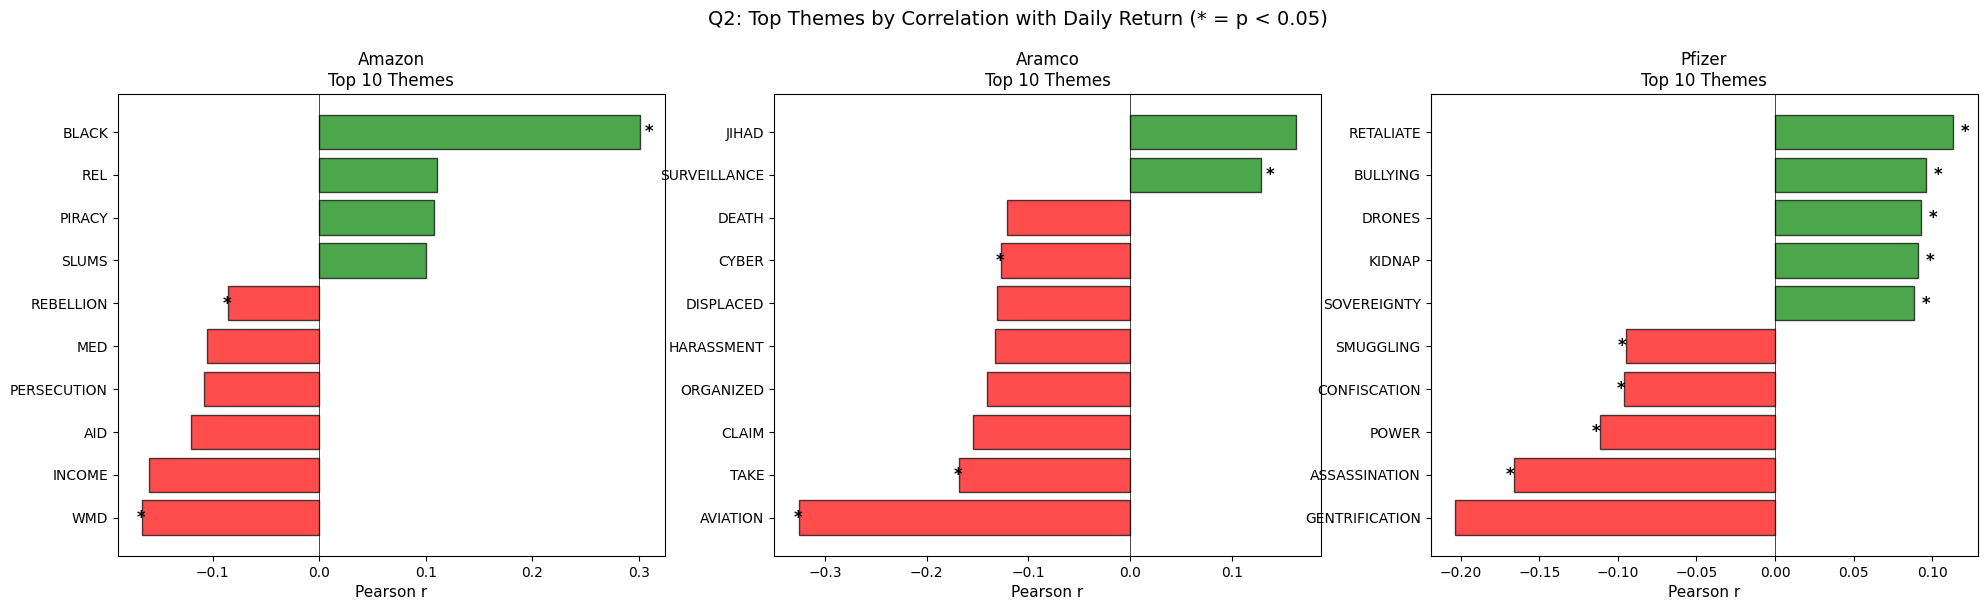

In [15]:

companies = sorted(top_themes.keys())
fig, axes = plt.subplots(1, len(companies), figsize=(8 * len(companies), 6))

if len(companies) == 1:
    axes = [axes]

for ax, company in zip(axes, companies):
    top = top_themes[company].sort_values("theme_vs_return_r")
    colors = ["green" if r > 0 else "red" for r in top["theme_vs_return_r"]]

    ax.barh(top["theme_category"], top["theme_vs_return_r"], color=colors, alpha=0.7, edgecolor="black")
    ax.set_xlabel("Pearson r", fontsize=11)
    ax.set_title(f"{company}\nTop 10 Themes", fontsize=12)
    ax.axvline(x=0, color="black", linewidth=0.5)

    # Add stars for significant themes
    for i, (_, row) in enumerate(top.iterrows()):
        if row["theme_vs_return_significant"] == "Yes":
            x_pos = row["theme_vs_return_r"]
            offset = 0.005 if x_pos >= 0 else -0.005
            ax.text(x_pos + offset, i, "*", va="center", fontsize=12, fontweight="bold")

fig.suptitle("Q2: Top Themes by Correlation with Daily Return (* = p < 0.05)", fontsize=14, y=1.02)
plt.show()

Fig 2.2: Bar chart showing how many themes are significant per company for each metric (next-day close vs daily return).

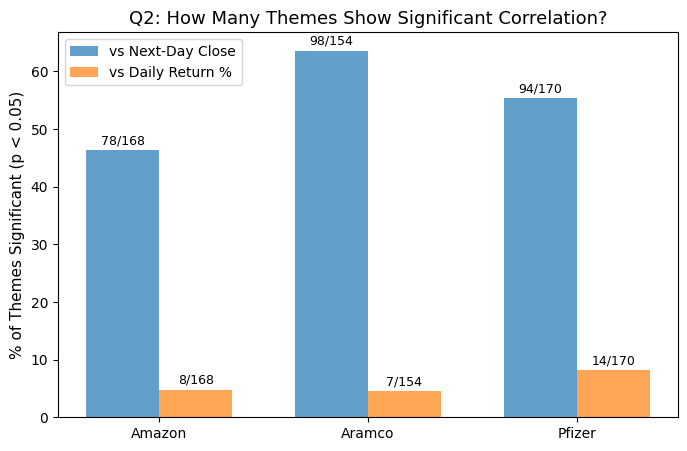

In [16]:
summary = []
for company in sorted(results_df["company"].unique()):
    company_data = results_df[results_df["company"] == company]
    total = len(company_data)
    sig_close = len(company_data[company_data["theme_vs_close_significant"] == "Yes"])
    sig_return = len(company_data[company_data["theme_vs_return_significant"] == "Yes"])
    summary.append({
        "company": company,
        "total_themes": total,
        "sig_close": sig_close,
        "sig_return": sig_return,
        "pct_sig_close": round(sig_close / total * 100, 1) if total > 0 else 0,
        "pct_sig_return": round(sig_return / total * 100, 1) if total > 0 else 0,
    })

summary_df = pd.DataFrame(summary)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary_df))
width = 0.35

ax.bar(x - width / 2, summary_df["pct_sig_close"], width, label="vs Next-Day Close", color="#1f77b4", alpha=0.7)
ax.bar(x + width / 2, summary_df["pct_sig_return"], width, label="vs Daily Return %", color="#ff7f0e", alpha=0.7)

ax.set_ylabel("% of Themes Significant (p < 0.05)", fontsize=11)
ax.set_title("Q2: How Many Themes Show Significant Correlation?", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(summary_df["company"], fontsize=10)
ax.legend(fontsize=10)

# Add count labels on bars
for i, row in summary_df.iterrows():
    ax.text(i - width / 2, row["pct_sig_close"] + 1, f"{row['sig_close']}/{row['total_themes']}",
            ha="center", fontsize=9)
    ax.text(i + width / 2, row["pct_sig_return"] + 1, f"{row['sig_return']}/{row['total_themes']}",
            ha="center", fontsize=9)

plt.show()

Q3: Is there correlation between the exposure of an organization and stock prices during 2020-2025?

In [18]:
df = load_data(SENTIMENT_DATA_PATH)

Loaded 6518 rows from ./files/cleaned_data-combined_data_clean_000000000000-2.csv
Companies: ['Aramco' 'Amazon' 'Pfizer']
Date range: 2020-01-02 00:00:00 to 2025-12-30 00:00:00


In [19]:
def run_exposure_correlations(df):
    """
    Run Pearson correlation for each company:
      - daily_exposure_count vs next_day_close  (exposure vs price level)
      - daily_exposure_count vs daily_return_pct (exposure vs daily movement)
 
    Consistent with Q1 tone script — same two targets.
    """
    results = []
 
    for company in sorted(df["company"].unique()):
        company_df = df[df["company"] == company]
        n = len(company_df)
 
        # Exposure vs Next-Day Close (price level)
        r_close, p_close = pearsonr(
            company_df["daily_exposure_count"], company_df["next_day_close"]
        )
 
        # Exposure vs Daily Return % (daily movement)
        r_return, p_return = pearsonr(
            company_df["daily_exposure_count"], company_df["daily_return_pct"]
        )
 
        results.append({
            "company": company,
            "n_observations": n,
            "exposure_vs_close_r": round(r_close, 4),
            "exposure_vs_close_p": round(p_close, 6),
            "exposure_vs_close_significant": "Yes" if p_close < 0.05 else "No",
            "exposure_vs_return_r": round(r_return, 4),
            "exposure_vs_return_p": round(p_return, 6),
            "exposure_vs_return_significant": "Yes" if p_return < 0.05 else "No",
        })
 
    results_df = pd.DataFrame(results)
    return results_df

def print_exp_results(results_df):
    """Print main correlation results with hypothesis test interpretation."""
    print("\n" + "=" * 70)
    print("Q3 RESULTS: Is there correlation between media exposure and stock prices?")
    print("=" * 70)
    print(f"Null hypothesis: No significant relationship between exposure and price")
    print(f"Significance level: alpha = 0.05")
    print("-" * 70)
 
    for _, row in results_df.iterrows():
        print(f"\n{row['company']} (n={row['n_observations']}):")
        print(f"  Exposure vs Next-Day Close:  r={row['exposure_vs_close_r']:.4f}, "
              f"p={row['exposure_vs_close_p']:.6f}  --> "
              f"{'REJECT null (significant)' if row['exposure_vs_close_significant'] == 'Yes' else 'FAIL TO REJECT null (not significant)'}")
        print(f"  Exposure vs Daily Return %:  r={row['exposure_vs_return_r']:.4f}, "
              f"p={row['exposure_vs_return_p']:.6f}  --> "
              f"{'REJECT null (significant)' if row['exposure_vs_return_significant'] == 'Yes' else 'FAIL TO REJECT null (not significant)'}")


results_df = run_exposure_correlations(df)
print_exp_results(results_df)


Q3 RESULTS: Is there correlation between media exposure and stock prices?
Null hypothesis: No significant relationship between exposure and price
Significance level: alpha = 0.05
----------------------------------------------------------------------

Amazon (n=2173):
  Exposure vs Next-Day Close:  r=0.0410, p=0.056041  --> FAIL TO REJECT null (not significant)
  Exposure vs Daily Return %:  r=0.0174, p=0.418842  --> FAIL TO REJECT null (not significant)

Aramco (n=2172):
  Exposure vs Next-Day Close:  r=-0.1712, p=0.000000  --> REJECT null (significant)
  Exposure vs Daily Return %:  r=-0.0398, p=0.063558  --> FAIL TO REJECT null (not significant)

Pfizer (n=2173):
  Exposure vs Next-Day Close:  r=0.1950, p=0.000000  --> REJECT null (significant)
  Exposure vs Daily Return %:  r=0.0335, p=0.118919  --> FAIL TO REJECT null (not significant)


Fig 3.1: Bar chart comparing r-values across companies for both metrics.

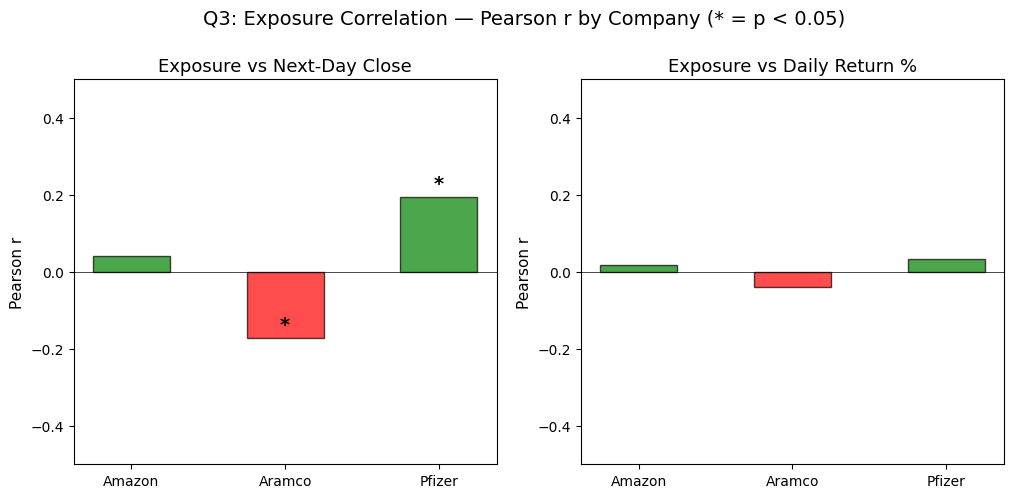

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

companies = results_df["company"]
x = np.arange(len(companies))
width = 0.5

# Exposure vs Next-Day Close
colors_close = ["green" if r > 0 else "red" for r in results_df["exposure_vs_close_r"]]
axes[0].bar(x, results_df["exposure_vs_close_r"], width, color=colors_close, alpha=0.7, edgecolor="black")
axes[0].set_ylabel("Pearson r", fontsize=11)
axes[0].set_title("Exposure vs Next-Day Close", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(companies, fontsize=10)
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].set_ylim(-0.5, 0.5)
for i, row in results_df.iterrows():
    if row["exposure_vs_close_significant"] == "Yes":
        axes[0].text(i, row["exposure_vs_close_r"] + 0.02, "*", ha="center", fontsize=14, fontweight="bold")
 
# Exposure vs Daily Return
colors_ret = ["green" if r > 0 else "red" for r in results_df["exposure_vs_return_r"]]
axes[1].bar(x, results_df["exposure_vs_return_r"], width, color=colors_ret, alpha=0.7, edgecolor="black")
axes[1].set_ylabel("Pearson r", fontsize=11)
axes[1].set_title("Exposure vs Daily Return %", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(companies, fontsize=10)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylim(-0.5, 0.5)
for i, row in results_df.iterrows():
    if row["exposure_vs_return_significant"] == "Yes":
        axes[1].text(i, row["exposure_vs_return_r"] + 0.02, "*", ha="center", fontsize=14, fontweight="bold")

fig.suptitle("Q3: Exposure Correlation — Pearson r by Company (* = p < 0.05)", fontsize=14, y=1.02)
plt.show()

Fig 3.2: Scatter plot

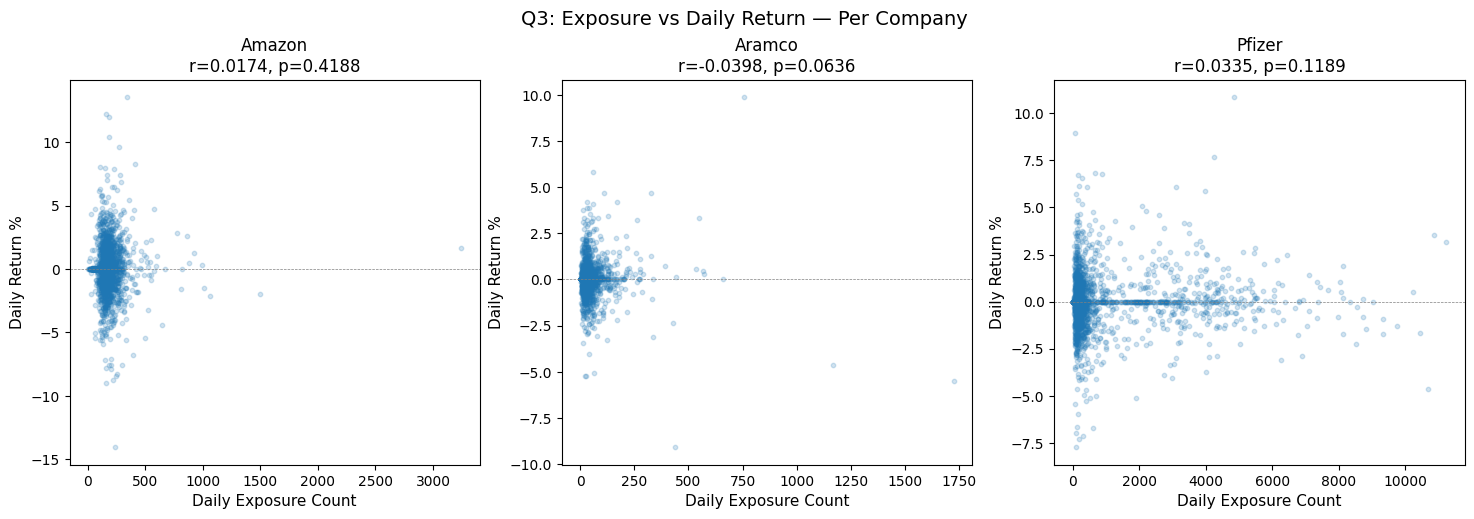

In [21]:
companies = sorted(df["company"].unique())
fig, axes = plt.subplots(1, len(companies), figsize=(6 * len(companies), 5))

if len(companies) == 1:
    axes = [axes]

for ax, company in zip(axes, companies):
    company_df = df[df["company"] == company]
    r, p = pearsonr(company_df["daily_exposure_count"], company_df["daily_return_pct"])

    ax.scatter(
        company_df["daily_exposure_count"],
        company_df["daily_return_pct"],
        alpha=0.2, s=10, color="#1f77b4"
    )
    ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Daily Exposure Count", fontsize=11)
    ax.set_ylabel("Daily Return %", fontsize=11)
    ax.set_title(f"{company}\nr={r:.4f}, p={p:.4f}", fontsize=12)

fig.suptitle("Q3: Exposure vs Daily Return — Per Company", fontsize=14, y=1.02)
plt.show()